<a href="https://colab.research.google.com/github/Ronald-Tuncar/LAB-06-MDD/blob/develop/LAB08_Arboles_y_Bosques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LABORATORIO 08: ÁRBOLES DE DECISIÓN Y BOSQUES ALEATORIOS
**Nombres:**

MINAYA TORRES TERRY ,
TUNCAR ANDIA RONALD


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [ ]:
# Dataset: Breast Cancer Wisconsin (Original)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
columnas = ['ID','Clump_Thickness','Uniformity_Cell_Size','Uniformity_Cell_Shape',
            'Marginal_Adhesion','Single_Epithelial_Cell_Size','Bare_Nuclei',
            'Bland_Chromatin','Normal_Nucleoli','Mitoses','Class']
df = pd.read_csv(url, names=columnas)

# Eliminamos la  columna ID
df.drop('ID', axis=1, inplace=True)

# Reemplazamos '?' y convertimos a numérico
df.replace('?', np.nan, inplace=True)
df['Bare_Nuclei'] = pd.to_numeric(df['Bare_Nuclei'])

# Realizamos la imputación de valores faltantes
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Hacemos Separación de variables
X = df_imputed.drop('Class', axis=1)
y = df_imputed['Class']

# Luego hacemos la división del dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


ÁRBOL DE DECISIÓN
[[115   3]
 [  8  49]]
              precision    recall  f1-score   support

         2.0       0.93      0.97      0.95       118
         4.0       0.94      0.86      0.90        57

    accuracy                           0.94       175
   macro avg       0.94      0.92      0.93       175
weighted avg       0.94      0.94      0.94       175

Precisión: 0.9371428571428572


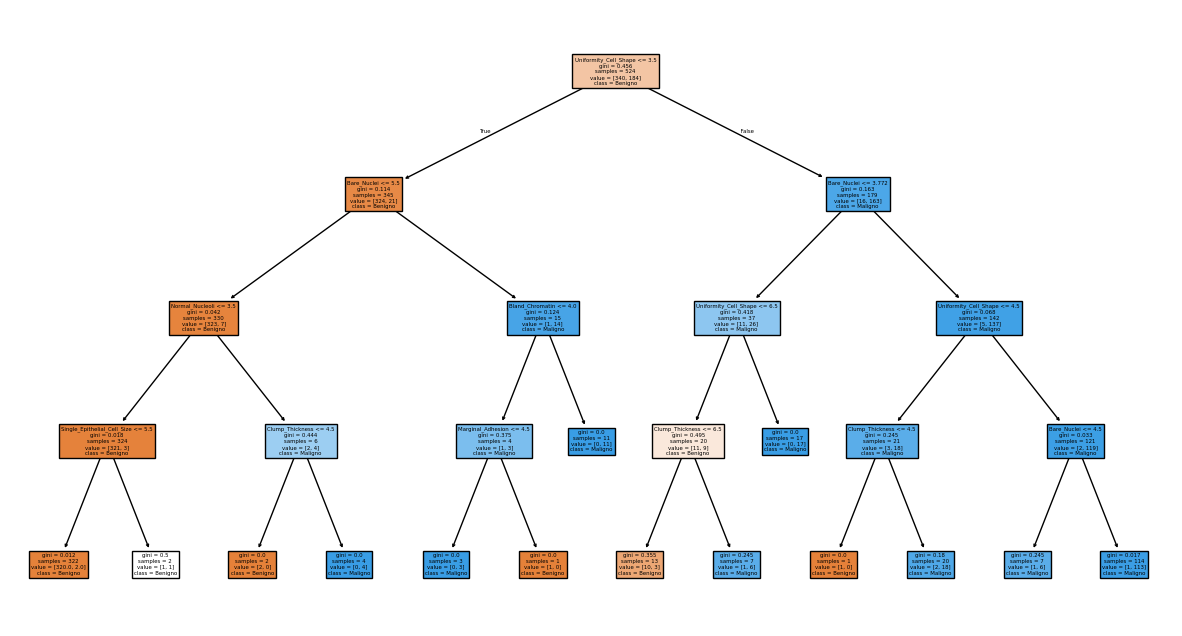

In [ ]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)

print("ÁRBOL DE DECISIÓN")
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))
print("Precisión:", accuracy_score(y_test, y_pred_tree))

plt.figure(figsize=(15, 8))
plot_tree(tree_clf, feature_names=X.columns, class_names=["Benigno", "Maligno"], filled=True)
plt.show()


In [ ]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("BOSQUE ALEATORIO")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Precisión:", accuracy_score(y_test, y_pred_rf))


BOSQUE ALEATORIO
[[115   3]
 [  3  54]]
              precision    recall  f1-score   support

         2.0       0.97      0.97      0.97       118
         4.0       0.95      0.95      0.95        57

    accuracy                           0.97       175
   macro avg       0.96      0.96      0.96       175
weighted avg       0.97      0.97      0.97       175

Precisión: 0.9657142857142857
